#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [1]:
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import RobustScaler

from haversine import haversine, Unit
from sklearn.impute import KNNImputer
import math

import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
### carga datos del dataset 
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [4]:
columnas = ['key', 'pickup_datetime', 'passenger_count', 
                   'pickup_longitude', 'pickup_latitude', 
                   'dropoff_longitude', 'dropoff_latitude']
columna_target = 'fare_amount'

# Crear X e y iniciales
X = df[columnas].copy()
y = df[columna_target].copy()

# División inicial train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=None)

In [5]:
# Definir los límites geográficos de Nueva York (Manhattan y áreas cercanas)
NY_COORDENADAS = {
    'min_lat': 40.4774,      # Sur de Manhattan
    'max_lat': 40.9176,      # Norte de Manhattan/Bronx
    'min_lon': -74.2591,     # Oeste de Manhattan
    'max_lon': -73.7004      # Este de Brooklyn/Queens
}

In [6]:
def validar_coordenadas(df, bounds=NY_COORDENADAS):
    """
    Valida y filtra coordenadas dentro de los límites de Nueva York
    Retorna máscaras booleanas para pickup y dropoff válidos
    """
    # Crear máscaras para coordenadas válidas
    valid_pickup = (
        (df['pickup_latitude'] >= bounds['min_lat']) &
        (df['pickup_latitude'] <= bounds['max_lat']) &
        (df['pickup_longitude'] >= bounds['min_lon']) &
        (df['pickup_longitude'] <= bounds['max_lon'])
    )

    valid_dropoff = (
        (df['dropoff_latitude'] >= bounds['min_lat']) &
        (df['dropoff_latitude'] <= bounds['max_lat']) &
        (df['dropoff_longitude'] >= bounds['min_lon']) &
        (df['dropoff_longitude'] <= bounds['max_lon'])
    )

    # Identificar outliers extremos
    extreme_pickup_lat = df[~valid_pickup]['pickup_latitude'].dropna()
    extreme_pickup_lon = df[~valid_pickup]['pickup_longitude'].dropna()

    return valid_pickup, valid_dropoff

In [7]:
def limpiar_coordenadas(X_train, X_test, y_train, y_test):
    """
    Limpia y filtra las coordenadas de Nueva York 
    Modifica y_train, y_test para mantener consistencia
    """

    # Validar coordenadas para TRAIN
    valid_pickup_train, valid_dropoff_train = validar_coordenadas(X_train)
    valid_mask_train = valid_pickup_train & valid_dropoff_train
    
    # Validar coordenadas para TEST
    valid_pickup_test, valid_dropoff_test = validar_coordenadas(X_test)
    valid_mask_test = valid_pickup_test & valid_dropoff_test

    # Aplicar limpieza - OPCIÓN 1: Eliminar registros inválidos (recomendado)
    
    # Filtrar TRAIN
    X_train_filtered = X_train[valid_mask_train].copy()
    y_train_filtered = y_train[valid_mask_train].copy()
    
    # Filtrar TEST
    X_test_filtered = X_test[valid_mask_test].copy()
    y_test_filtered = y_test[valid_mask_test].copy()

    # Calcular distancia de viaje 
    def calculate_distance(row):
        return haversine(
                (row['pickup_latitude'], row['pickup_longitude']),
                (row['dropoff_latitude'], row['dropoff_longitude']),
                unit=Unit.KILOMETERS)


    # Para TRAIN - eliminar distancia 0
    X_train_filtered['distance_km'] = X_train_filtered.apply(calculate_distance, axis=1)
    zero_distance_train = X_train_filtered['distance_km'] == 0
    if zero_distance_train.sum() > 0:
        X_train_filtered = X_train_filtered[~zero_distance_train].copy()
        y_train_filtered = y_train_filtered[~zero_distance_train].copy()

    # Para TEST - eliminar distancia 0
    X_test_filtered['distance_km'] = X_test_filtered.apply(calculate_distance, axis=1)
    zero_distance_test = X_test_filtered['distance_km'] == 0
    if zero_distance_test.sum() > 0:
        X_test_filtered = X_test_filtered[~zero_distance_test].copy()
        y_test_filtered = y_test_filtered[~zero_distance_test].copy()

    return X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered

In [8]:
def procesar_datos_temporales_y_limpieza(X_train, X_test, y_train, y_test):
    
    # PROCESAR CARACTERÍSTICAS TEMPORALES PARA TRAIN
    X_train_copy = X_train.copy()
    
    # Convertir a datetime (manejar formato UTC)
    X_train_copy['pickup_datetime'] = pd.to_datetime(X_train_copy['pickup_datetime'].str.replace(' UTC', ''), utc=True)

    # Extraer día de la semana (0=Lunes, 6=Domingo)
    X_train_copy['day_week_num'] = X_train_copy['pickup_datetime'].dt.dayofweek

    # Encoding circular para día de la semana
    sin_col = f"day_week_num_sin"
    cos_col = f"day_week_num_cos"
    X_train_copy[sin_col] = np.sin(2 * np.pi * X_train_copy['day_week_num'] / 7)
    X_train_copy[cos_col] = np.cos(2 * np.pi * X_train_copy['day_week_num'] / 7)

    # Extraer hora
    X_train_copy['hora'] = X_train_copy['pickup_datetime'].dt.hour

    # Crear categorías de período del día
    etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
    bins = [0, 6, 12, 18, 24]
    X_train_copy['period_of_the_day'] = pd.cut(X_train_copy['hora'], bins=bins,
                                            labels=etiquetas, right=False, include_lowest=True)

    # Encoding circular para hora
    sin_col_hora = f"hora_sin"
    cos_col_hora = f"hora_cos"
    X_train_copy[sin_col_hora] = np.sin(2 * np.pi * X_train_copy['hora'] / 24)
    X_train_copy[cos_col_hora] = np.cos(2 * np.pi * X_train_copy['hora'] / 24)

    # PROCESAR CARACTERÍSTICAS TEMPORALES PARA TEST
    X_test_copy = X_test.copy()
    
    # Convertir a datetime 
    X_test_copy['pickup_datetime'] = pd.to_datetime(X_test_copy['pickup_datetime'].str.replace(' UTC', ''), utc=True)

    # Extraer día de la semana (0=Lunes, 6=Domingo)
    X_test_copy['day_week_num'] = X_test_copy['pickup_datetime'].dt.dayofweek

    # Encoding circular para día de la semana
    sin_col = f"day_week_num_sin"
    cos_col = f"day_week_num_cos"
    X_test_copy[sin_col] = np.sin(2 * np.pi * X_test_copy['day_week_num'] / 7)
    X_test_copy[cos_col] = np.cos(2 * np.pi * X_test_copy['day_week_num'] / 7)

    # Extraer hora
    X_test_copy['hora'] = X_test_copy['pickup_datetime'].dt.hour

    # Crear categorías de período del día
    X_test_copy['period_of_the_day'] = pd.cut(X_test_copy['hora'], bins=bins,
                                            labels=etiquetas, right=False, include_lowest=True)

    # Encoding circular para hora
    X_test_copy[sin_col_hora] = np.sin(2 * np.pi * X_test_copy['hora'] / 24)
    X_test_copy[cos_col_hora] = np.cos(2 * np.pi * X_test_copy['hora'] / 24)
    
    # LIMPIEZA DE OUTLIERS - PASAJEROS (TRAIN)
    valid_passengers_mask_train = X_train_copy['passenger_count'] <= 10
    X_train_filtered = X_train_copy[valid_passengers_mask_train].copy()
    y_train_filtered = y_train[valid_passengers_mask_train].copy()

    # LIMPIEZA DE OUTLIERS - FARE_AMOUNT (<0) (TRAIN)
    initial_rows_fare_train = len(X_train_filtered)
    valid_fare_mask_train = y_train_filtered >= 0
    X_train_final = X_train_filtered[valid_fare_mask_train].copy()
    y_train_final = y_train_filtered[valid_fare_mask_train].copy()
    
    # LIMPIEZA DE OUTLIERS - PASAJEROS (TEST)
    valid_passengers_mask_test = X_test_copy['passenger_count'] <= 10          # REVISAR SI HACE FALTA APLICAR A TEST!!!!!
    X_test_filtered = X_test_copy[valid_passengers_mask_test].copy()
    y_test_filtered = y_test[valid_passengers_mask_test].copy()

    # LIMPIEZA DE OUTLIERS - FARE_AMOUNT (<0) (TEST)
    initial_rows_fare_test = len(X_test_filtered)                       
    valid_fare_mask_test = y_test_filtered >= 0
    X_test_final = X_test_filtered[valid_fare_mask_test].copy()
    y_test_final = y_test_filtered[valid_fare_mask_test].copy()


    return X_train_final, X_test_final, y_train_final, y_test_final

In [9]:
# LIMPIEZA DE COORDENADAS
X_train, X_test, y_train, y_test = limpiar_coordenadas(X_train, X_test, y_train, y_test)

# PROCESAMIENTO TEMPORAL
X_train, X_test, y_train, y_test = procesar_datos_temporales_y_limpieza(X_train, X_test, y_train, y_test)

In [10]:
X_train.head()

,key,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,day_week_num,day_week_num_sin,day_week_num_cos,hora,period_of_the_day,hora_sin,hora_cos
153248,17778666,2009-11-19 21:59:00+00:00,1,-73.978585,40.748388,-73.976913,40.784958,4.068841,3,0.433884,-0.900969,21,Noche,-0.707107,0.707107
67802,54334677,2013-02-27 22:29:15+00:00,1,-73.978198,40.752533,-73.909752,40.874372,14.721602,2,0.974928,-0.222521,22,Noche,-0.500000,0.866025
148889,11815656,2014-06-01 08:48:00+00:00,1,-73.994242,40.751227,-73.999432,40.762037,1.279042,6,-0.781831,0.623490,8,Mañana,0.866025,-0.500000
103093,28734805,2010-07-10 23:10:00+00:00,2,-73.951705,40.778330,-73.956050,40.777560,0.375743,5,-0.974928,-0.222521,23,Noche,-0.258819,0.965926
104681,54482655,2013-09-29 13:36:00+00:00,1,-73.989120,40.736932,-73.782890,40.643947,20.229724,6,-0.781831,0.623490,13,Tarde,-0.258819,-0.965926


In [11]:
X_train.describe()

,key,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,day_week_num,day_week_num_sin,day_week_num_cos,hora,hora_sin,hora_cos
count,1.548560e+05,154856.000000,154856.000000,154856.000000,154856.000000,154856.000000,154856.000000,154856.000000,154856.000000,154856.000000,154856.000000,154856.000000,154856.000000
mean,2.770093e+07,1.683738,-73.975689,40.750824,-73.974753,40.751143,3.342711,3.049943,-0.001186,-0.043074,13.479258,-0.193448,-0.069664
std,1.602606e+07,1.307309,0.034150,0.026725,0.033659,0.030517,3.555644,1.947839,0.711524,0.701344,6.514864,0.668720,0.714525
min,1.000000e+00,0.000000,-74.243432,40.498988,-74.244837,40.486242,0.000084,0.000000,-0.974928,-0.900969,0.000000,-1.000000,-1.000000
25%,1.378367e+07,1.000000,-73.992284,40.736525,-73.991642,40.735377,1.282854,1.000000,-0.781831,-0.900969,9.000000,-0.866025,-0.707107
50%,2.773996e+07,1.000000,-73.982160,40.753310,-73.980584,40.753750,2.183132,3.000000,0.000000,-0.222521,14.000000,-0.258819,-0.258819
75%,4.153730e+07,2.000000,-73.968581,40.767480,-73.965592,40.768348,3.932616,5.000000,0.781831,0.623490,19.000000,0.500000,0.707107
max,5.542357e+07,6.000000,-73.702735,40.917048,-73.700650,40.916956,35.341909,6.000000,0.974928,1.000000,23.000000,1.000000,1.000000


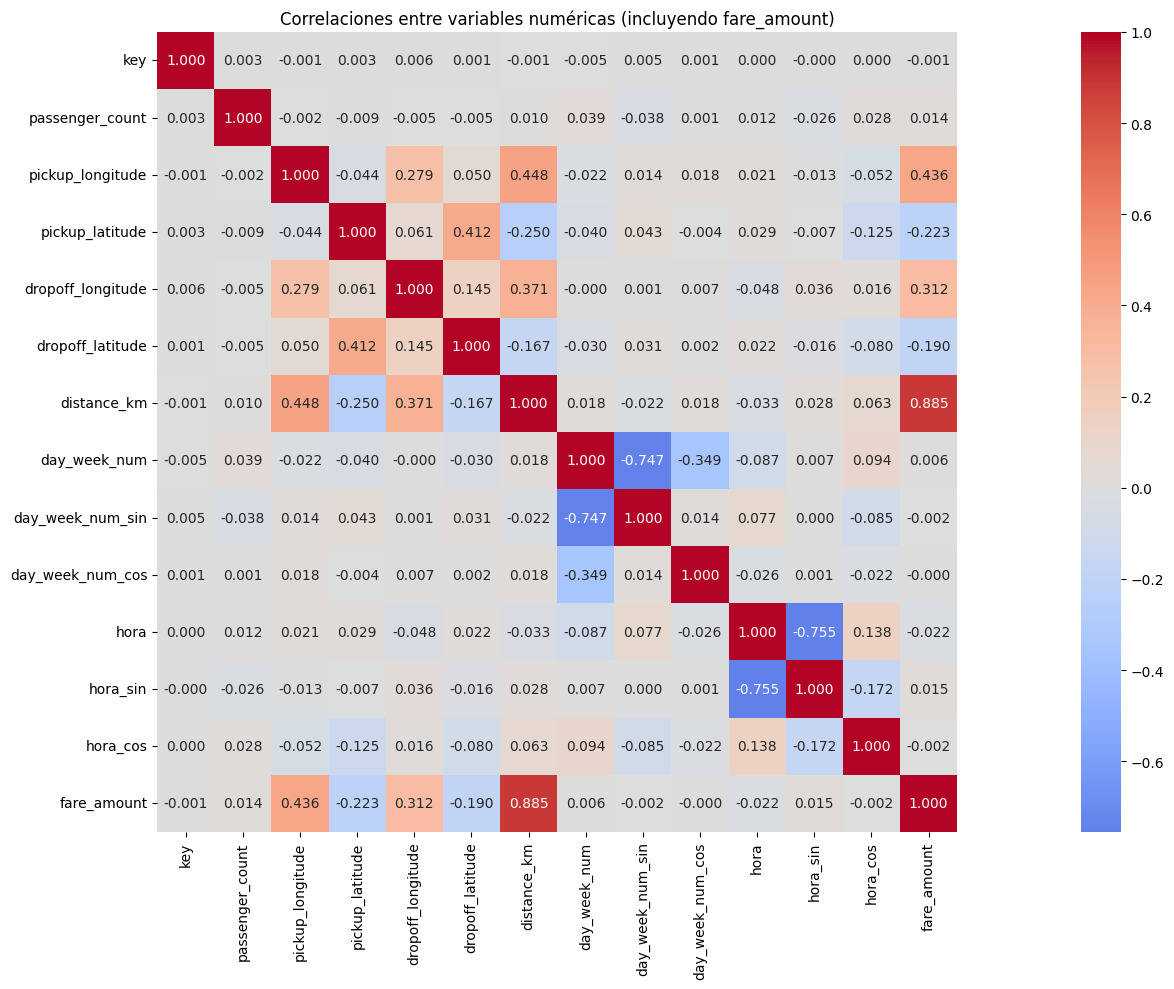

In [12]:
# Crear dataframe temporal que incluya y_train para el análisis de correlación
df_train_temp = X_train.copy()
df_train_temp['fare_amount'] = y_train

# Seleccionar solo columnas numéricas para la matriz de correlación
numeric_cols = df_train_temp.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# Visualización de correlaciones
plt.figure(figsize=(25, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlaciones entre variables numéricas (incluyendo fare_amount)')
plt.tight_layout()
plt.show()

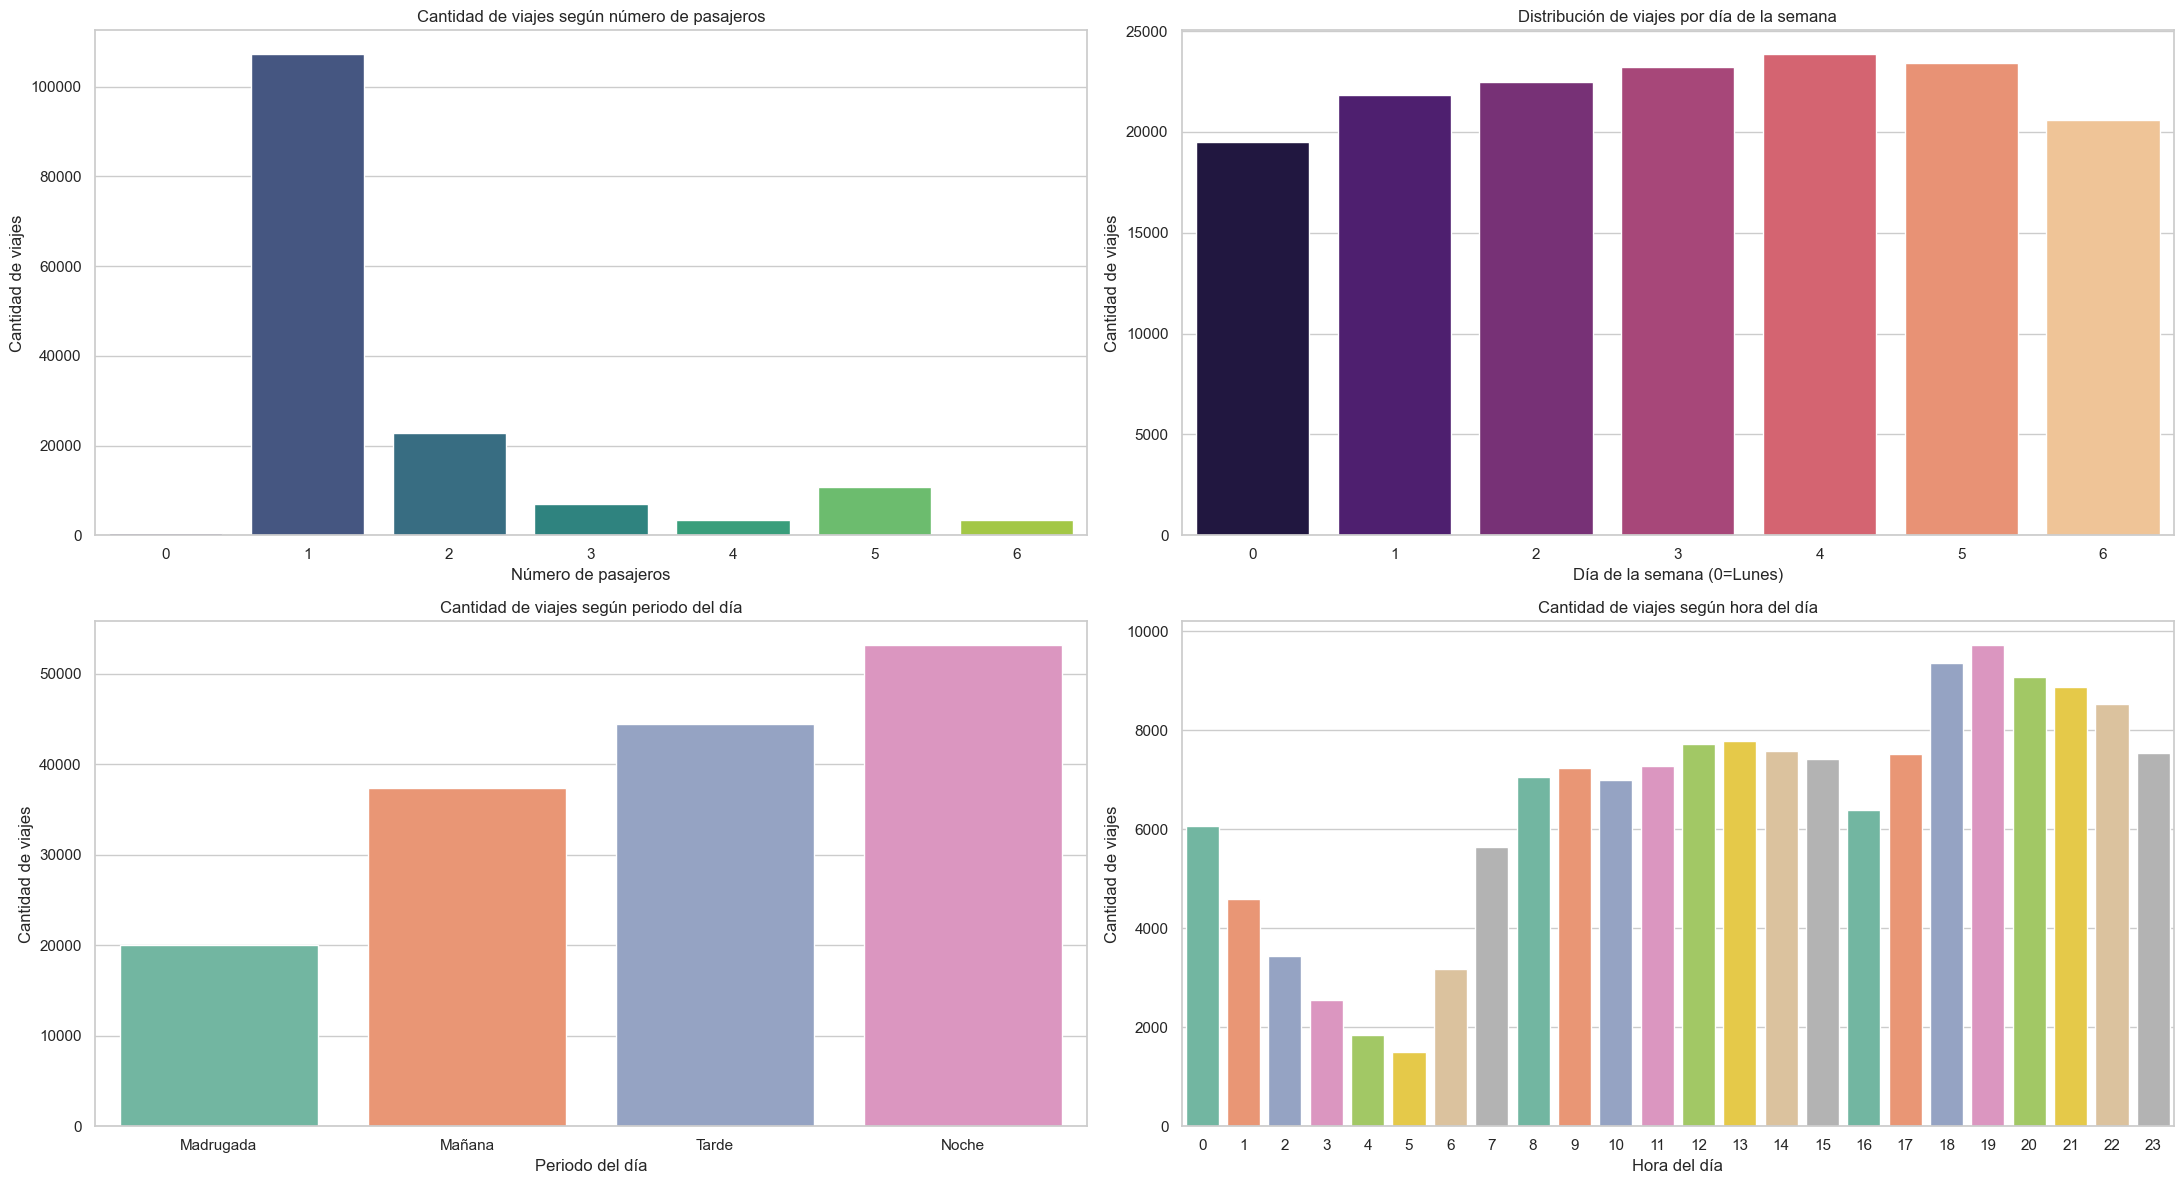

In [13]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Conteo de viajes por cantidad de pasajeros
sns.countplot(data=X_train, x="passenger_count", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Cantidad de viajes según número de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por día de la semana
order_days = [0, 1, 2, 3, 4, 5, 6]  # Lunes=0 ... Domingo=6
sns.countplot(data=X_train, x="day_week_num", order=order_days, ax=axes[0,1], palette="magma")
axes[0,1].set_title("Distribución de viajes por día de la semana")
axes[0,1].set_xlabel("Día de la semana (0=Lunes)")
axes[0,1].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="period_of_the_day",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[1,0],
    palette="Set2"
)
axes[1,0].set_title("Cantidad de viajes según periodo del día")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="hora",
    ax=axes[1,1],
    palette="Set2"
)
axes[1,1].set_title("Cantidad de viajes según hora del día")
axes[1,1].set_xlabel("Hora del día")
axes[1,1].set_ylabel("Cantidad de viajes")


plt.tight_layout()
plt.show()

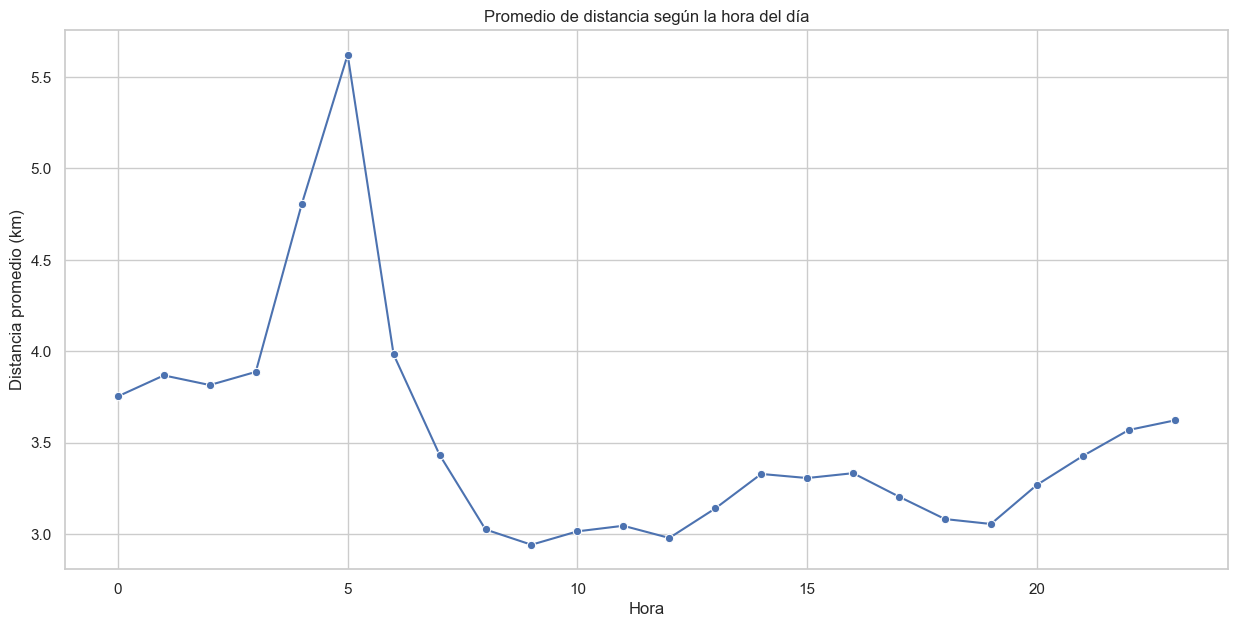

In [14]:
# Promedio de distancia según hora del día

plt.figure(figsize=(15,7))
sns.lineplot(data=X_train, x="hora", y="distance_km", estimator="mean", ci=None, marker="o")
plt.title("Promedio de distancia según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Distancia promedio (km)")
plt.show()

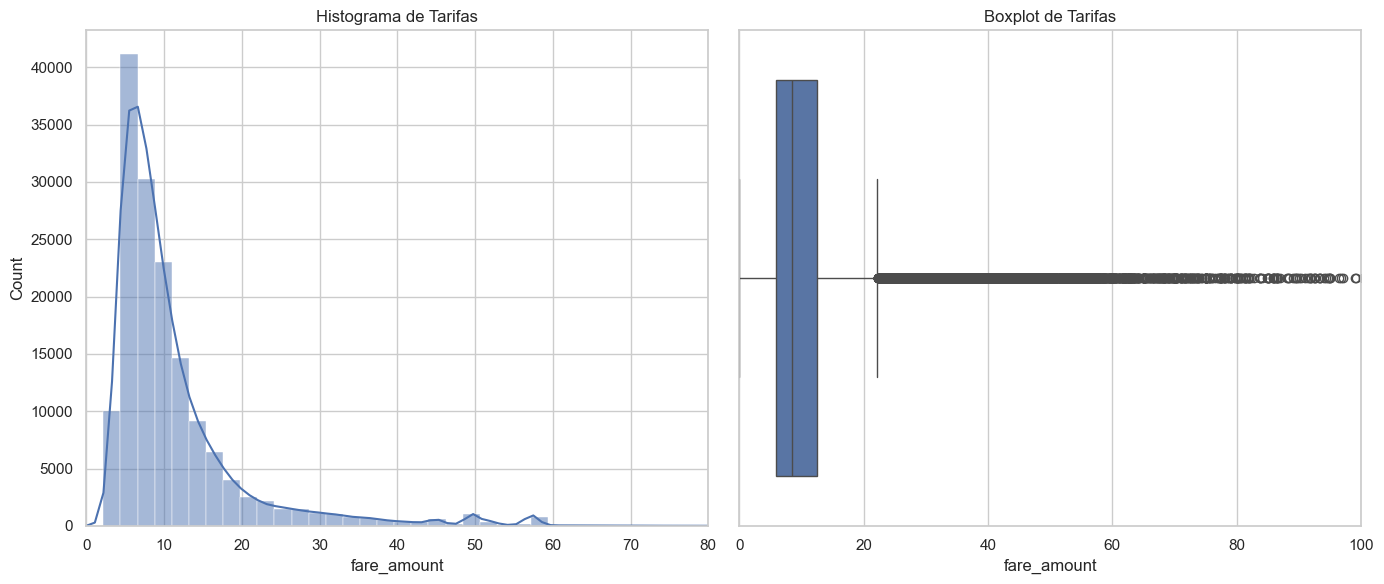

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de tarifas
sns.histplot(y_train, bins=100, kde=True, ax=axes[0])
axes[0].set_xlim(0, 80)  # límite para ver mejor la zona central
axes[0].set_title("Histograma de Tarifas")

# Boxplot de tarifas
sns.boxplot(x=y_train, ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title("Boxplot de Tarifas")

plt.tight_layout()
plt.show()

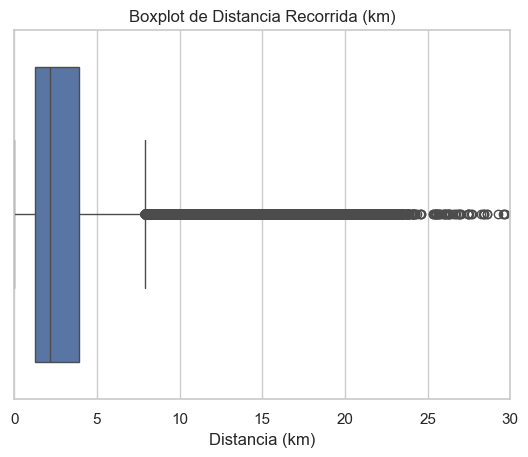

In [16]:
# Boxplot distancia
sns.boxplot(x=X_train['distance_km'])
plt.title("Boxplot de Distancia Recorrida (km)")
plt.xlabel("Distancia (km)")
plt.xlim(0, 30) 
plt.show()

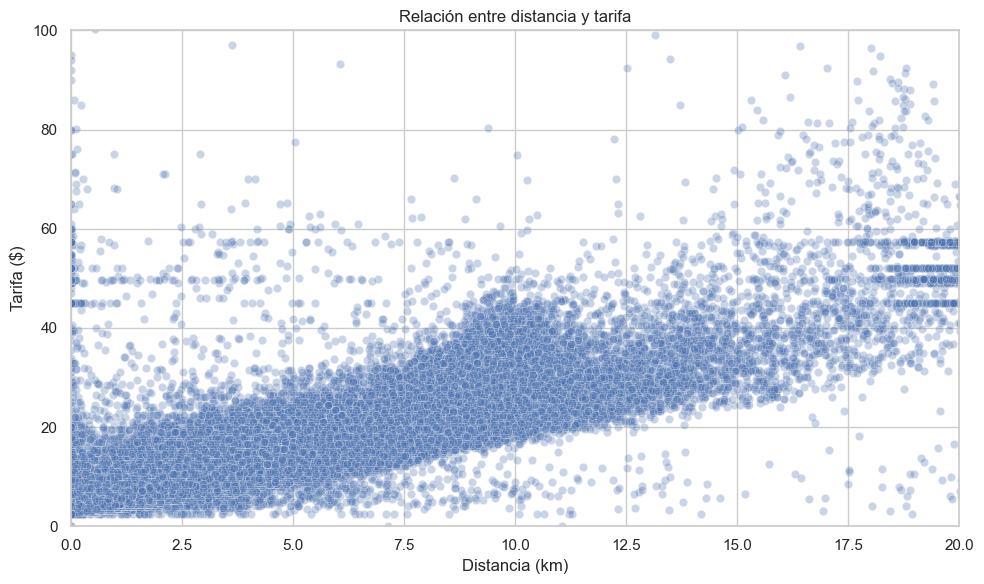

In [17]:
# Relación entre distancia y tarifa (dispersión)
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x=X_train["distance_km"], y=y_train, alpha=0.3)
plt.xlim(0, 20)   # Limitar a 20 km para evitar outliers extremos
plt.ylim(0, 100)  # Limitar a 100 dólares para evitar outliers extremos
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

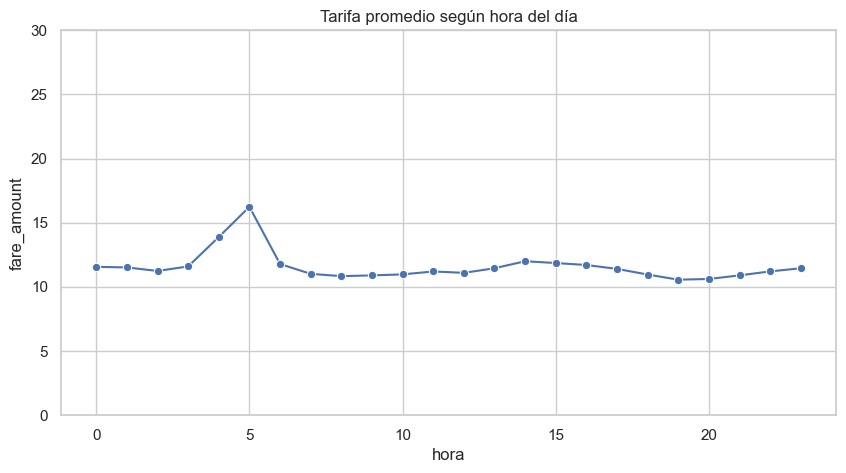

In [18]:
# Fare por hora del día

plt.figure(figsize=(10,5))
sns.lineplot(x=X_train["hora"], y=y_train, estimator="mean", errorbar=None, marker="o")
plt.ylim(0, 30)
plt.title("Tarifa promedio según hora del día")
plt.show()

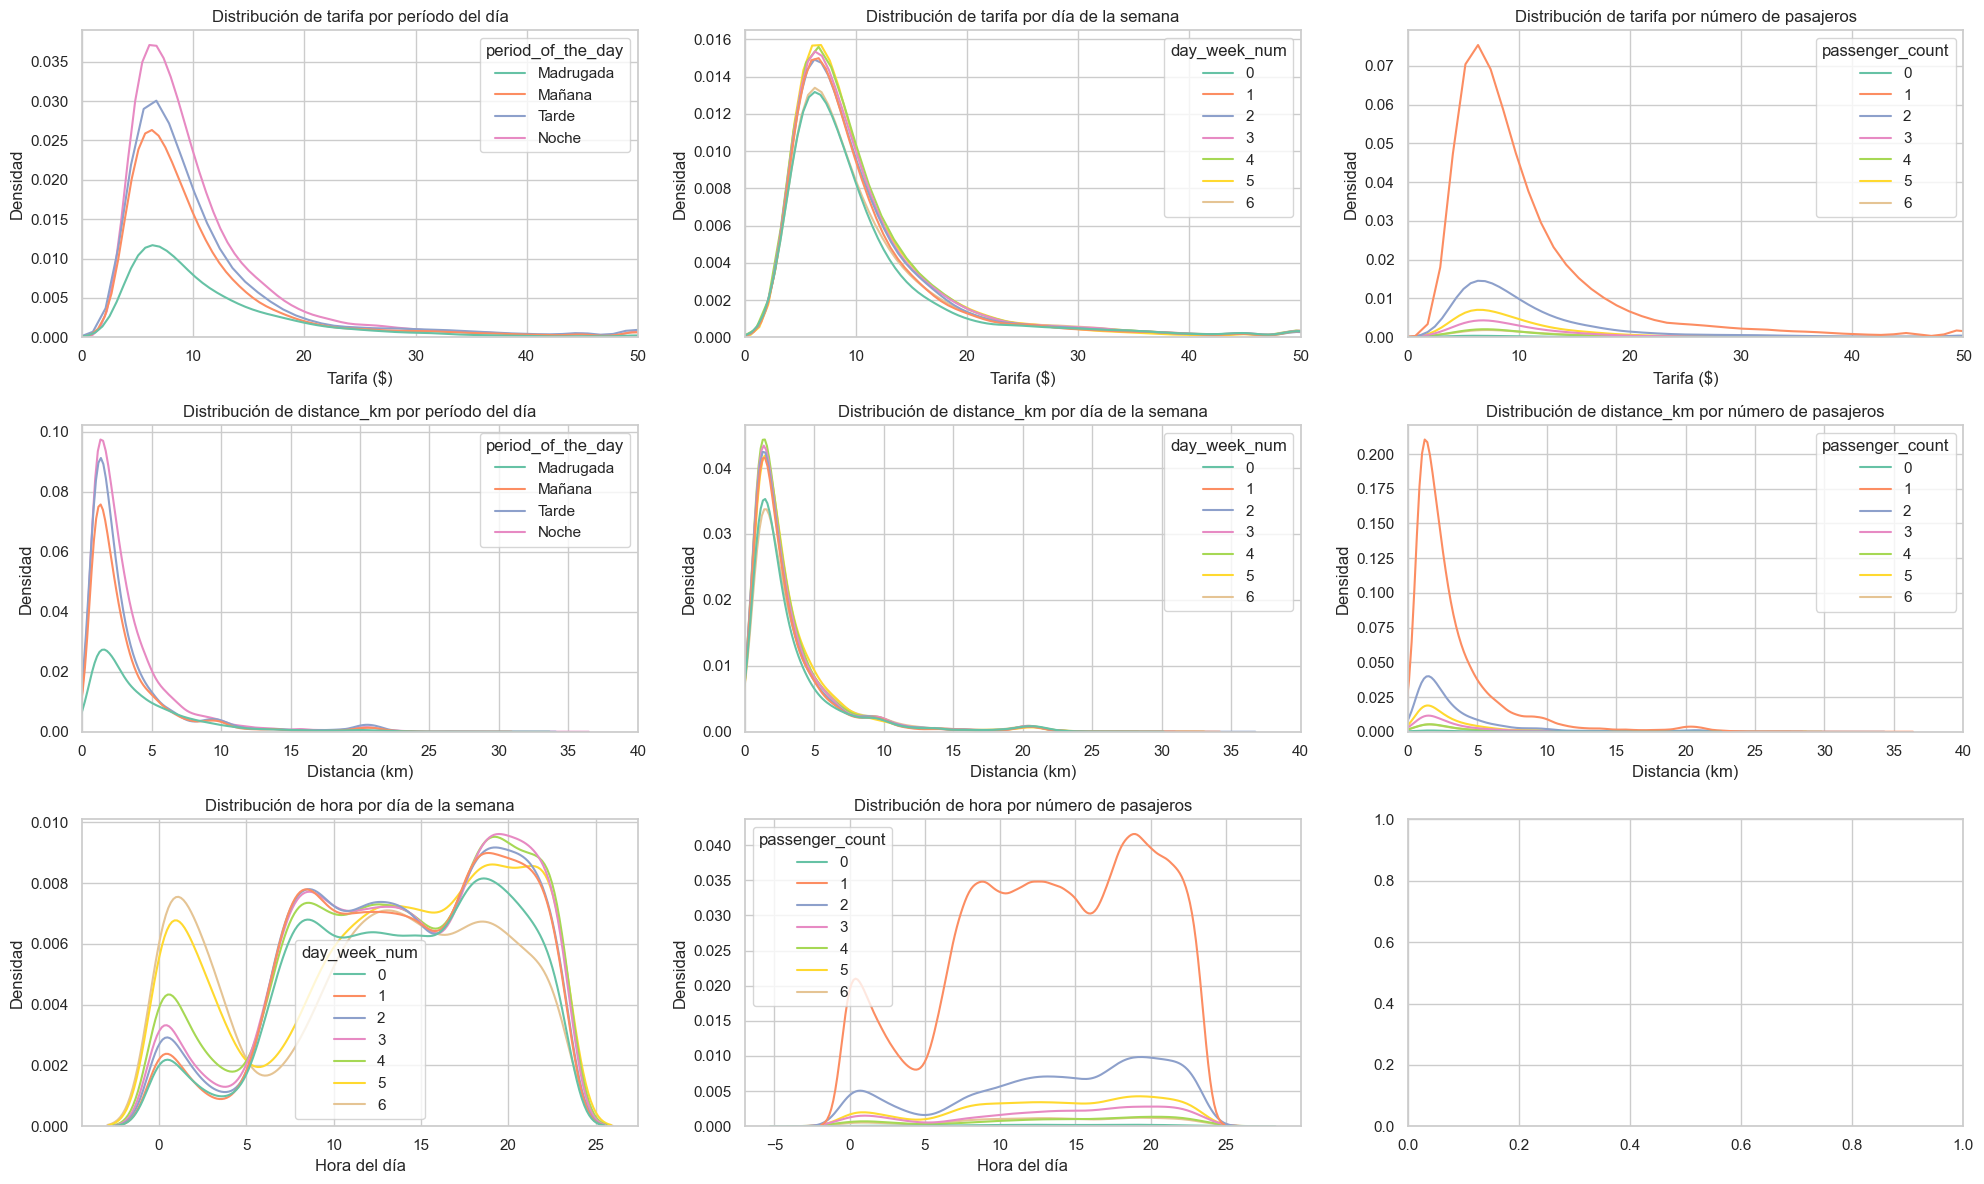

In [19]:
fig, ((ax1, ax2, ax3) ,(ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))

# Combinar X_train y y_train para los gráficos de target
data_combined = X_train.copy()
data_combined['target'] = y_train

# Gráfico 1: Distribución de la variable objetivo por período del día
sns.kdeplot(data=data_combined, x='target', hue='period_of_the_day', palette='Set2', ax=ax1)
ax1.set_xlim(0, 50)
ax1.set_title("Distribución de tarifa por período del día")
ax1.set_xlabel("Tarifa ($)")
ax1.set_ylabel("Densidad")

# Gráfico 2: Distribución de la variable objetivo por día de la semana
sns.kdeplot(data=data_combined, x='target', hue='day_week_num', palette='Set2', ax=ax2)
ax2.set_xlim(0, 50)
ax2.set_title("Distribución de tarifa por día de la semana")
ax2.set_xlabel("Tarifa ($)")
ax2.set_ylabel("Densidad")

# Gráfico 3: Distribución de la variable objetivo por número de pasajeros
sns.kdeplot(data=data_combined, x='target', hue='passenger_count', palette='Set2', ax=ax3)
ax3.set_xlim(0, 50)
ax3.set_title("Distribución de tarifa por número de pasajeros")
ax3.set_xlabel("Tarifa ($)")
ax3.set_ylabel("Densidad")

# Gráfico 4: Distribución de distance_km por período del día
sns.kdeplot(data=X_train, x='distance_km', hue='period_of_the_day', palette='Set2', ax=ax4)
ax4.set_xlim(0, 40)
ax4.set_title("Distribución de distance_km por período del día")
ax4.set_xlabel("Distancia (km)")
ax4.set_ylabel("Densidad")

# Gráfico 5: Distribución de distance_km por día de la semana
sns.kdeplot(data=X_train, x='distance_km', hue='day_week_num', palette='Set2', ax=ax5)
ax5.set_xlim(0, 40)
ax5.set_title("Distribución de distance_km por día de la semana")
ax5.set_xlabel("Distancia (km)")
ax5.set_ylabel("Densidad")

# Gráfico 6: Distribución de distance_km por número de pasajeros
sns.kdeplot(data=X_train, x='distance_km', hue='passenger_count', palette='Set2', ax=ax6)
ax6.set_xlim(0, 40)
ax6.set_title("Distribución de distance_km por número de pasajeros")
ax6.set_xlabel("Distancia (km)")
ax6.set_ylabel("Densidad")

# Gráfico 7: Distribución de hora por día de la semana
sns.kdeplot(data=X_train, x='hora', hue='day_week_num', palette='Set2', ax=ax7)
ax7.set_title("Distribución de hora por día de la semana")
ax7.set_xlabel("Hora del día")
ax7.set_ylabel("Densidad")

# Gráfico 8: Distribución de hora por número de pasajeros
sns.kdeplot(data=X_train, x='hora', hue='passenger_count', palette='Set2', ax=ax8)
ax8.set_title("Distribución de hora por número de pasajeros")
ax8.set_xlabel("Hora del día")
ax8.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

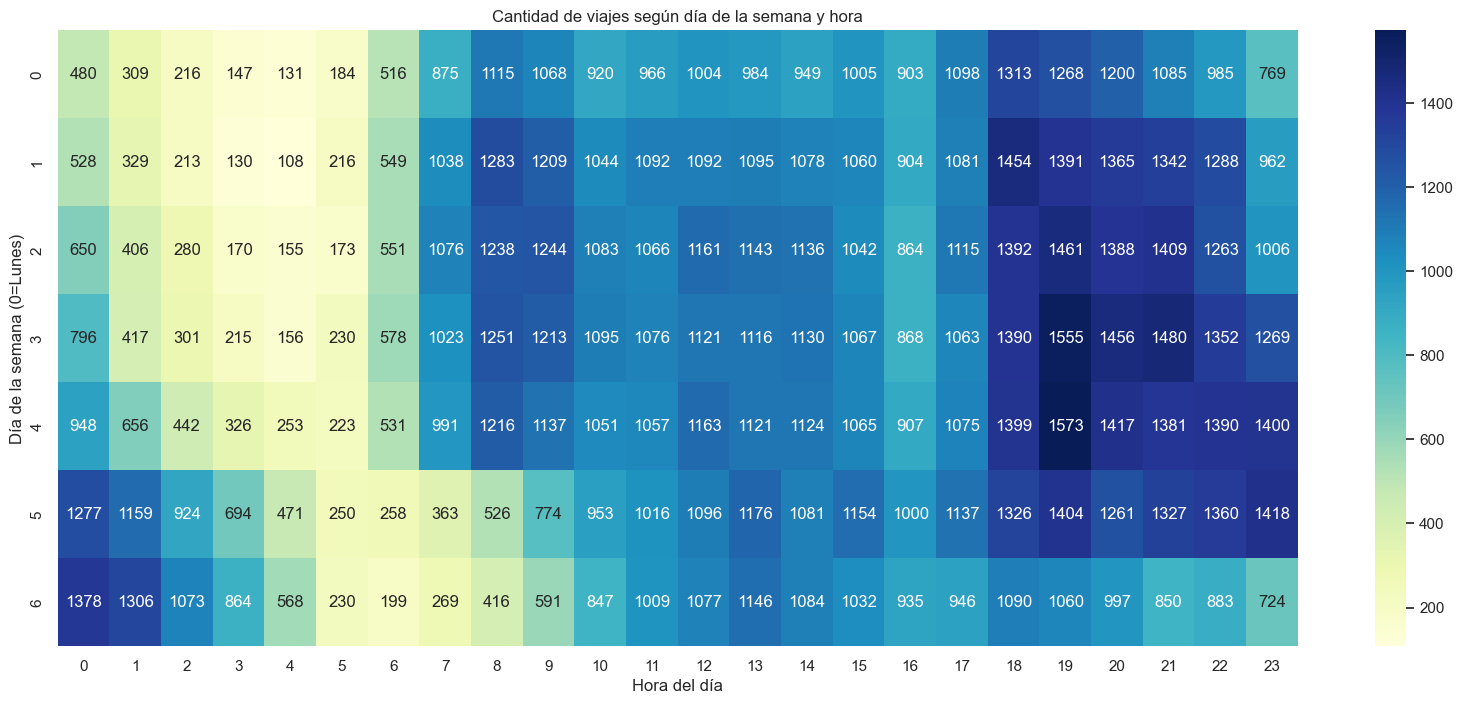

In [20]:
# Heatmap hora vs día de la semana

pivot_data = X_train.groupby(['day_week_num','hora']).size().unstack(fill_value=0)
plt.figure(figsize=(20,8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Cantidad de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

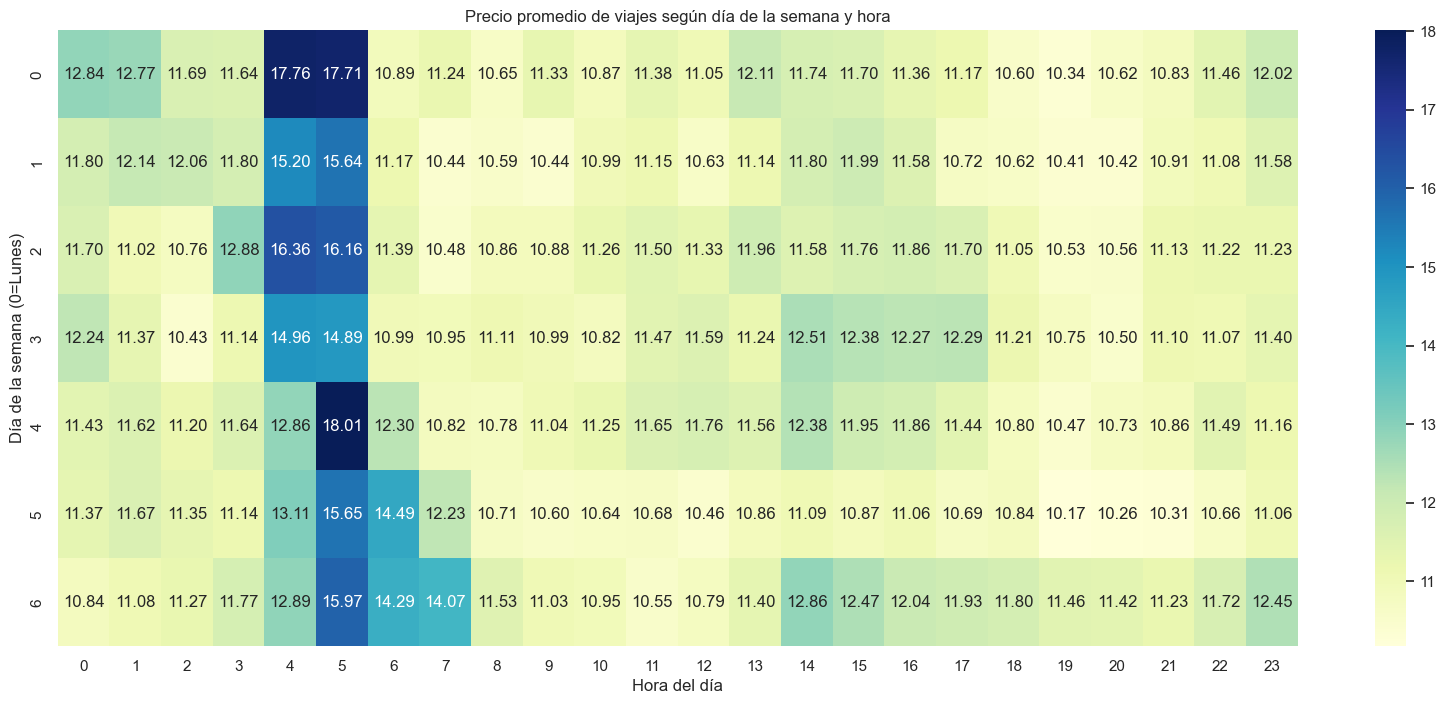

In [21]:
# Heatmap precio promedio vs día de la semana y hora

# Combinar X_train y y_train
data_combined = X_train[['day_week_num', 'hora']].copy()
data_combined['target'] = y_train

# Agrupar por día de la semana y hora, y calcular el precio promedio
pivot_data = data_combined.groupby(['day_week_num', 'hora'])['target'].mean().unstack(fill_value=0)

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Precio promedio de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

In [22]:
X_train

,key,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,day_week_num,day_week_num_sin,day_week_num_cos,hora,period_of_the_day,hora_sin,hora_cos
153248,17778666,2009-11-19 21:59:00+00:00,1,-73.978585,40.748388,-73.976913,40.784958,4.068841,3,0.433884,-0.900969,21,Noche,-0.707107,0.707107
67802,54334677,2013-02-27 22:29:15+00:00,1,-73.978198,40.752533,-73.909752,40.874372,14.721602,2,0.974928,-0.222521,22,Noche,-0.500000,0.866025
148889,11815656,2014-06-01 08:48:00+00:00,1,-73.994242,40.751227,-73.999432,40.762037,1.279042,6,-0.781831,0.623490,8,Mañana,0.866025,-0.500000
103093,28734805,2010-07-10 23:10:00+00:00,2,-73.951705,40.778330,-73.956050,40.777560,0.375743,5,-0.974928,-0.222521,23,Noche,-0.258819,0.965926
104681,54482655,2013-09-29 13:36:00+00:00,1,-73.989120,40.736932,-73.782890,40.643947,20.229724,6,-0.781831,0.623490,13,Tarde,-0.258819,-0.965926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,1659846,2011-02-24 17:50:00+00:00,1,-73.975727,40.755598,-73.972682,40.764690,1.043008,3,0.433884,-0.900969,17,Tarde,-0.965926,-0.258819
103694,1041443,2013-10-06 19:53:00+00:00,2,-73.987458,40.750500,-73.983002,40.743627,0.851456,6,-0.781831,0.623490,19,Noche,-0.965926,0.258819
131932,53427452,2012-04-21 13:51:00+00:00,1,-73.992855,40.758665,-74.001943,40.734407,2.803914,5,-0.974928,-0.222521,13,Tarde,-0.258819,-0.965926
146867,50554992,2009-09-01 19:39:00+00:00,5,-73.960555,40.757512,-73.958520,40.766328,0.995166,1,0.781831,0.623490,19,Noche,-0.965926,0.258819


In [23]:
X_train = X_train.drop('key', axis=1)
X_test = X_test.drop('key', axis=1)
X_train = X_train.drop('pickup_datetime', axis=1)
X_test = X_test.drop('pickup_datetime', axis=1)
X_train = X_train.drop('period_of_the_day', axis=1)
X_test = X_test.drop('period_of_the_day', axis=1)

In [24]:
# Escalado robusto para características numéricas
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# Predicciones sobre el conjunto de entrenamiento
y_pred_train = model_lr.predict(X_train_scaled)

# Métricas
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = math.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

print("Métricas en el conjunto de entrenamiento:")
print(f'Error Cuadrático Medio: {round(mse_train, 3)}')
print(f'Raíz Error Cuadrático Medi: {round(rmse_train, 3)}')
print(f'Coeficiente de Determinación: {round(r2_train, 3)}')

Métricas en el conjunto de entrenamiento:
Error Cuadrático Medio: 18.264
Raíz Error Cuadrático Medi: 4.274
Coeficiente de Determinación: 0.792


In [27]:
# Predicciones sobre el conjunto de test
y_pred = model_lr.predict(X_test_scaled)

# Métricas
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = math.sqrt(mse_test) # mean_squared_error(y_test_op1, y_pred_op1, squared=False)
r2_test = r2_score(y_test, y_pred)

print("\nMétricas en el conjunto de testeo:")
print(f'Error Cuadrático Medio: {round(mse_test, 3)}')
print(f'Raíz Error Cuadrático Medio: {round(rmse_test, 3)}')
print(f'Coeficiente de Determinación: {round(r2_test, 3)}')


Métricas en el conjunto de testeo:
Error Cuadrático Medio: 26.319
Raíz Error Cuadrático Medio: 5.13
Coeficiente de Determinación: 0.727


In [28]:
# Coeficientes de la recta de regresión
intercepto = model_lr.intercept_
print(f"Intercepto: {intercepto}")
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': model_lr.coef_.flatten()}
                  )

df_coeficientes[df_coeficientes.coef != 0]

Intercepto: 8.718382836054857


,predictor,coef
0,passenger_count,0.047679
1,pickup_longitude,0.344290
2,pickup_latitude,0.125488
3,dropoff_longitude,-0.106534
4,dropoff_latitude,-0.566855
5,distance_km,6.042339
6,day_week_num,-0.039584
7,day_week_num_sin,0.241088
8,day_week_num_cos,-0.373045
9,hora,-0.041004


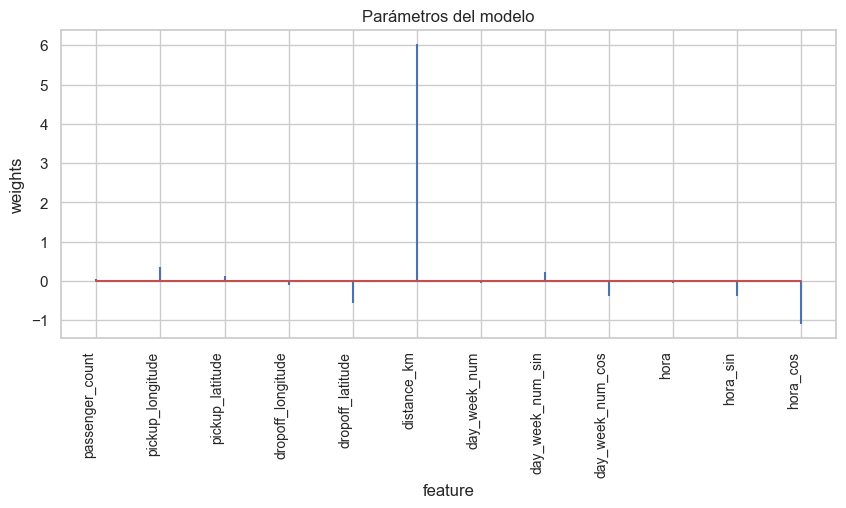

In [29]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame({'predictor': X_train.columns, 'coef': df_coeficientes.coef})

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo')
plt.show()

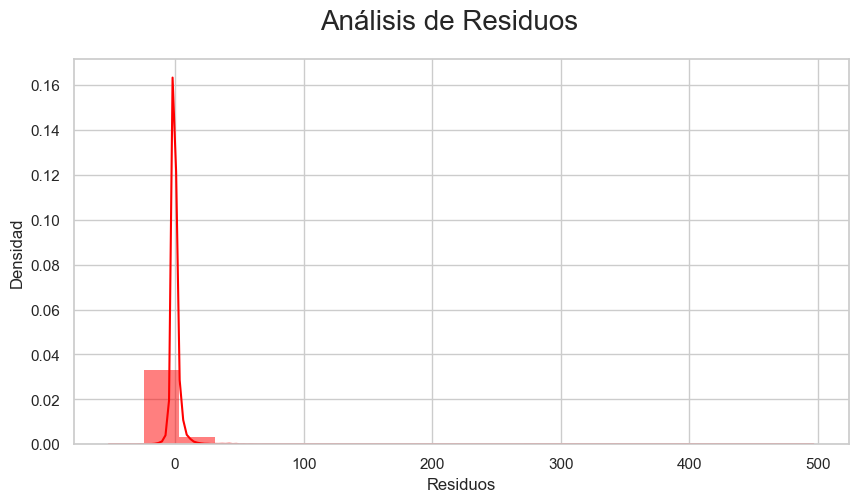

In [30]:
# Análisis de Residuos
fig = plt.figure(figsize=(10,5))

sns.histplot((y_test - y_pred), color="red", kde=True, stat="density", linewidth=0, bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)
plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.show()

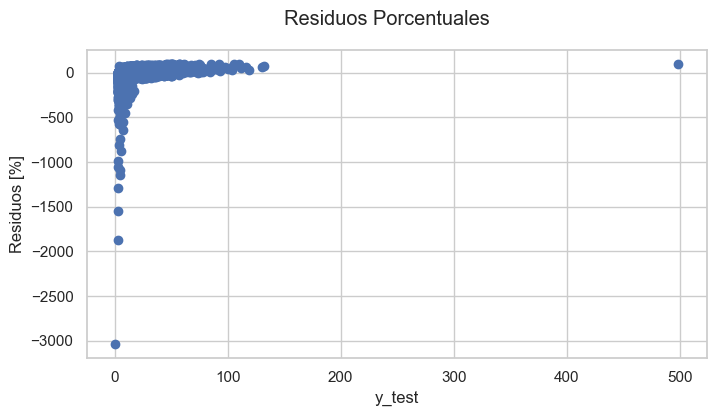

In [31]:
fig = plt.figure(figsize=(8,4))
fig.suptitle('Residuos Porcentuales')
plt.xlabel('y_test')
plt.ylabel('Residuos [%]')
plt.scatter(y_test,100*(y_test-y_pred)/y_test)
plt.show()

# Gradiente descendiente


In [32]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_test = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [33]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)



    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

In [34]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

In [35]:
# Agregar arriba de todo
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

In [36]:
X_train.shape, X_val.shape, X_test.shape

NameError: name 'X_val' is not defined

In [ ]:
# Convertir a numpy arrays y asegurar shapes correctos
X_train = np.array(X_train)  # Shape: (135485, 13)
X_val = np.array(X_val)      # Shape: (19355, 13)
y_train = np.array(y_train).reshape(-1, 1)  # Shape: (135485, 1)
y_val = np.array(y_val).reshape(-1, 1)      # Shape: (19355, 1)
X_test = np.array(X_test)    # Shape: (38710, 13)
y_test = np.array(y_test).reshape(-1, 1)    # Shape: (38710, 1)

In [ ]:
# Verificar shapes
print("Shapes después de conversión:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val: {y_val.shape}")

## Gradiente Descendiente Convencional

In [ ]:
# Ahora llamar a la función
W = gradient_descent(X_train, y_train, X_val, y_val, lr=0.1, epochs=200)

## Gradiente Descendiente Estocastico

In [ ]:
stochastic_gradient_descent(X_train, y_train, X_val, y_val, lr=1, epochs=2)
# epoch 1 = 8.5s

## Gradiente Descendiente Mini Batch

In [ ]:
mini_batch_gradient_descent(X_train, y_train, X_test, y_test, epochs=10)
# epochs=200 llego a 3min

# Regularizacion

## Lasso

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Mostrar coeficientes
print("\nCoeficientes del modelo Lasso:")
print(lasso.coef_)
print(lasso.score(X_train_scaled,y_train))

## Ridge

ridge = Ridge(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Mostrar coeficientes
print("\nCoeficientes del modelo Ridge:")
print(ridge.coef_)
print(ridge.score(X_train_scaled,y_train))

## Elastic Net